<a href="https://colab.research.google.com/github/DaniloDuque/neural-network/blob/main/src/tp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP3 — Redes Neuronales

Este notebook está organizado en 4 secciones principales:

1. **Multilayer Perceptron** — Desarrollo de un perceptron multicapa con GD con momentum. (La documentación se encuentra en LaTeX)
2. **Clasificación de Función XOR** — Se utiliza MLP para la clasificación del XOR, con una serie de configuraciones.
3. **Clasificador en R²** — 4 configuraciones de MLP (M=20/2, con/sin momentum) sobre datos separables y no separables.
4. **ACRIMA** — clasificación de imágenes de fondo de ojo (glaucoma vs. no glaucoma). Utilizando el MLP desarrollado y AlexNet. Ambos con calibración mediante Optuna.

**Modelo:** Perceptrón Multicapa con descenso de gradiente con momentum (Bishop, 2006).  

## Configuración del entorno

Se clona el repositorio si se ejecuta en Google Colab, se agrega `src/` al path de Python y se configuran las credenciales de Kaggle necesarias para la Sección 3.

In [1]:
## @brief Configura el entorno de ejecución (Colab o local).
#  Clona el repositorio si se ejecuta en Google Colab y ajusta el directorio de trabajo.
import os, sys
from dotenv import load_dotenv

if 'google.colab' in sys.modules:
    if not os.path.exists('neural-network'):
        os.system('git clone https://github.com/DaniloDuque/neural-network.git')
    if os.path.basename(os.getcwd()) != 'neural-network':
        os.chdir('neural-network')
    os.system('git pull')

sys.path.insert(0, os.path.abspath('src'))

In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        from google.colab import userdata
        os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
        os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')
        print('Credenciales cargadas desde Colab Secrets.')
    except Exception:
        # Corriendo desde VS Code con extensión Colab — usar .env
        load_dotenv()
        print('Credenciales cargadas desde .env (extensión VS Code).')
else:
    kaggle_cfg = os.path.expanduser('~/.config/kaggle/kaggle.json')
    kagglehub_cache = os.path.expanduser('~/.cache/kagglehub/datasets/toaharahmanratul/acrima-dataset')
    if os.path.exists(kaggle_cfg):
        print(f'Credenciales encontradas en {kaggle_cfg}')
    elif os.path.exists(kagglehub_cache):
        print('Dataset ACRIMA ya en caché local — no se requieren credenciales.')
    else:
        print('ADVERTENCIA: no se encontró kaggle.json')

Credenciales cargadas desde Colab Secrets.


## Dependencias

Se instalan las dependencias necesarias para ejecutar el notebook.

In [6]:
## @brief Instala dependencias adicionales no incluidas en Colab.
import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'install',
                'kagglehub==0.3.13', 'Pillow', '-q'],
               check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'kagglehub==0.3.13', 'Pillow', '-q'], returncode=0)

## Dependencias e importaciones

Se importan todos los módulos del proyecto y se detecta el dispositivo de cómputo.

In [7]:
## @brief Importa todos los módulos del proyecto y configura el entorno.
#  Detecta el dispositivo disponible (CUDA o CPU) para pasarlo a las funciones de biblioteca.
!pip install optuna -q

import os
import sys
import subprocess
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import kagglehub
import optuna
from dotenv import load_dotenv

from multilayer_perceptron import MultilayerPerceptron
from data_generator        import generate_data, generate_moons_data
from data_classifier       import train_all_configs
from visualization         import (plot_datasets, plot_decision_surface_moons, plot_error_matrix,
                                   print_convergence_table, convergence_dataframe)
from xor_classifier        import (CONFIGS, CONVERGENCE_THRESHOLD,
                                    train_xor_configuration, convergence_epoch)
from acrima_dataset        import ACRIMADataset, encontrar_directorio_dataset
from hyperparameter_tuner  import HyperparameterTuner

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

FIGURES_DIR = Path('..') / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
RANDOM_SEED = 42


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.4 MB/s eta 0:00:00
Dispositivo: cuda


---
# Sección 1 — Desarrollo de Multilayer_Perceptron

Para ver los detalles visitar la documentación

---
# Sección 2 — Clasificación de Función XOR

Se entrena un MLP con arquitectura **[D, M, K] = [2, 2, 1]** sobre la tabla de verdad XOR.
El problema XOR no es linealmente separable: ningún hiperplano en R² puede dividir correctamente
las cuatro muestras. La capa oculta introduce una representación no lineal que permite al modelo
aprender la frontera de decisión correcta.

**Arquitectura:**
- D = 2 neuronas de entrada (x₁, x₂)
- M = 2 neuronas ocultas (representación no lineal)
- K = 1 neurona de salida (predicción binaria)

El bias es manejado internamente por `MultilayerPerceptron`.

In [ ]:
## @brief Define el dataset XOR.

X_xor = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
T_xor = torch.tensor([[0.], [1.], [1.], [0.]])
print('Dataset XOR:')
print(torch.cat([X_xor, T_xor], dim=1))

## 2.1 — Entrenamiento con múltiples configuraciones

In [ ]:
## @brief Entrena el MLP XOR con todas las configuraciones de hiperparámetros.
torch.manual_seed(RANDOM_SEED)

xor_results = [train_xor_configuration(alpha, gamma, num_epochs=40000) for alpha, gamma in CONFIGS]

for r in xor_results:
    print(f"α={r['alpha']:.2f}  γ={r['gamma']:.1f}  →  error final: {r['final_error']:.6f}")

## 2.2 — Curvas de aprendizaje

In [ ]:
## @brief Genera y guarda las curvas de aprendizaje MSE vs. iteraciones.
fig, ax = plt.subplots(figsize=(8, 5))

maxvalues = [max(r['errors']) for r in xor_results]

max_error = max(maxvalues)
for r in xor_results:
    ax.plot(r['errors'], label=f"α={r['alpha']:.2f} γ={r['gamma']:.1f}")
    # n = 0
    # for err in r['errors']:
    #     if(n%500==0):
    #         print(f"α={r['alpha']:.2f} γ={r['gamma']:.1f}  →  error: {err:.6f}  (época {n})")
    #     n+=1


ax.set_xlabel('Época')
ax.set_ylabel('Error MSE')
ax.set_title('XOR — Curvas de aprendizaje')
ax.legend()
ax.set_yscale('linear')
ax.set_ylim(1e-4, max_error)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xor_learning_curves.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'xor_learning_curves.png', bbox_inches='tight')
plt.show()

## 2.3 — Tabla de resultados

In [ ]:
## @brief Construye la tabla comparativa de hiperparámetros y error final.

df_xor = pd.DataFrame([
    {
        'α': r['alpha'],
        'γ': r['gamma'],
        'Error Final': r['final_error'],
        'Época Convergencia': convergence_epoch(r['errors'], CONVERGENCE_THRESHOLD),
    }
    for r in xor_results
])
df_xor

## 2.4 — Validación final (mejor configuración)

In [ ]:
## @brief Evalúa la mejor configuración y muestra las predicciones finales.
best = min(xor_results, key=lambda r: r['final_error'])
print(f"Mejor configuración: α={best['alpha']:.2f}  γ={best['gamma']:.1f}")
print(f"Error final: {best['final_error']:.6f}")
print(f"Época de convergencia: {convergence_epoch(best['errors'], CONVERGENCE_THRESHOLD)}")

preds = best['mlp'].predict(X_xor)

df_val = pd.DataFrame({
    'x₁': X_xor[:, 0].int().tolist(),
    'x₂': X_xor[:, 1].int().tolist(),
    'Esperado': T_xor.squeeze().int().tolist(),
    'Predicción': preds.squeeze().tolist(),
})
df_val

---
# Sección 3 — Clasificador de datos en R²

Se generan dos datasets (separable / no-separable) y se entrenan 4 configuraciones de MLP:

| Config | M  | γ   | Descripción               |
|--------|----|-----|---------------------------|
| A      | 20 | 0.9 | 20 neuronas, con momentum |
| B      | 20 | 0.0 | 20 neuronas, sin momentum |
| C      | 2  | 0.9 | 2 neuronas, con momentum  |
| D      | 2  | 0.0 | 2 neuronas, sin momentum  |

Partición 80% entrenamiento / 20% validación. α = 0.01 fijo para todas las configuraciones.

In [ ]:
## @brief Define hiperparámetros globales para la sección 2.
NUM_EPOCHS = 50

## 3.1 — Generación de datos

In [ ]:
## @brief Genera los datasets separable y no-separable con split 80/20.
X_train_s_b, X_val_s_b, T_train_s_b, T_val_s_b = generate_data(
    separable=True,  n_samples=500, test_size=0.2, random_state=42,
    device=torch.device(device)
)

X_train_ns_m, X_val_ns_m, T_train_ns_m, T_val_ns_m = generate_moons_data(
    noise=0.08, n_samples=500, test_size=0.2, random_state=42,
    device=torch.device(device)
)

#datos generado con make_blobs
print(f'Blobs: Separable    — train: {X_train_s_b.shape},  val: {X_val_s_b.shape}')

#datos generado con make_moons
print(f'Moons: No-separable — train: {X_train_ns_m.shape}, val: {X_val_ns_m.shape}')

## 3.2 — Visualización de los datos

In [ ]:
## @brief Muestra scatter de ambos datasets (train + val combinados).
X_sep_full   = torch.cat([X_train_s_b,  X_val_s_b],  dim=0).cpu()
T_sep_full   = torch.cat([T_train_s_b,  T_val_s_b],  dim=0).cpu()
X_nosep_full = torch.cat([X_train_ns_m, X_val_ns_m], dim=0).cpu()
T_nosep_full = torch.cat([T_train_ns_m, T_val_ns_m], dim=0).cpu()

fig = plot_datasets(X_sep_full, T_sep_full, X_nosep_full, T_nosep_full,
                    output_path=FIGURES_DIR / 'datasets_scatter.pdf')
plt.show()


## 3.3 — Entrenamiento de las 4 configuraciones

In [ ]:
## @brief Entrena las 4 configuraciones sobre el dataset separable.
results_sep_b = train_all_configs(
    X_train_s_b, T_train_s_b, X_val_s_b, T_val_s_b,
    num_epochs=NUM_EPOCHS
)


## @brief Entrena las 4 configuraciones sobre el dataset no-separable.
results_nosep_m = train_all_configs(
    X_train_ns_m, T_train_ns_m, X_val_ns_m, T_val_ns_m,
    num_epochs=NUM_EPOCHS
)

## 3.4 — Evolución del error

In [ ]:
## @brief Genera la matriz 2×4 de curvas de error train/val por configuración.
fig = plot_error_matrix(results_sep_b, results_nosep_m,
                        output_path=FIGURES_DIR / 'error_matrix.pdf')
plt.show()

## 3.5 — Tabla de convergencia

In [ ]:
## @brief Imprime la tabla de errores finales de validación por configuración.
print_convergence_table(results_sep_b, results_nosep_m)
convergence_dataframe(results_sep_b, results_nosep_m)

---
# Sección 4 — Clasificador de imágenes ACRIMA

Dataset: [ACRIMA en Kaggle](https://www.kaggle.com/datasets/toaharahmanratul/acrima-dataset) — imágenes de fondo de ojo etiquetadas con y sin glaucoma.

In [4]:
# ACRIMADataset y encontrar_directorio_dataset ya importados en la celda de dependencias.

In [8]:
## @brief Descarga el dataset ACRIMA desde Kaggle usando kagglehub.
#  La primera ejecución descarga (~1 GB). Las siguientes usan la caché local.
ACRIMA_PATH = kagglehub.dataset_download('toaharahmanratul/acrima-dataset')
print(f'Dataset descargado en: {ACRIMA_PATH}')

Using Colab cache for faster access to the 'acrima-dataset' dataset.
Dataset descargado en: /kaggle/input/acrima-dataset


In [9]:

train_dir = encontrar_directorio_dataset(ACRIMA_PATH)/"train"
test_dir  = Path(ACRIMA_PATH) / "test"


In [10]:


# Crear datasets
print("Dataset de entrenamiendo:")
dataset_train_mlp  = ACRIMADataset(train_dir, img_size=(64, 64))
dataset_train_alex = ACRIMADataset(train_dir, img_size=(224, 224))

print("Dataset de pruebas:")
dataset_test_mlp  = ACRIMADataset(test_dir, img_size=(64, 64))
dataset_test_alex = ACRIMADataset(test_dir, img_size=(224, 224))

Dataset de entrenamiendo:
  Normal: 239 imágenes
  Glaucoma: 326 imágenes
Total: 565 muestras
  Normal: 239 imágenes
  Glaucoma: 326 imágenes
Total: 565 muestras
Dataset de pruebas:
  Normal: 70 imágenes
  Glaucoma: 70 imágenes
Total: 140 muestras
  Normal: 70 imágenes
  Glaucoma: 70 imágenes
Total: 140 muestras


PRUEBA 1 — Verificación numérica: max(img_norm) debe ser ≈ 1.0
 Idx |  Max original |   Max norm |  Min norm | OK
-------------------------------------------------------
   0 |        198.00 |   1.000000 |  0.025126 | ✓
   1 |        255.00 |   1.000000 |  0.050980 | ✓
   2 |        220.00 |   1.000000 |  0.000000 | ✓
   3 |        173.00 |   1.000000 |  0.040230 | ✓
   4 |        248.00 |   1.000000 |  0.064516 | ✓
   5 |        255.00 |   1.000000 |  0.015686 | ✓
   6 |        255.00 |   1.000000 |  0.011765 | ✓
   7 |        255.00 |   1.000000 |  0.003922 | ✓
   8 |        255.00 |   1.000000 |  0.082353 | ✓
   9 |        255.00 |   1.000000 |  0.000000 | ✓

Resultado: PASÓ ✓ (10/10)


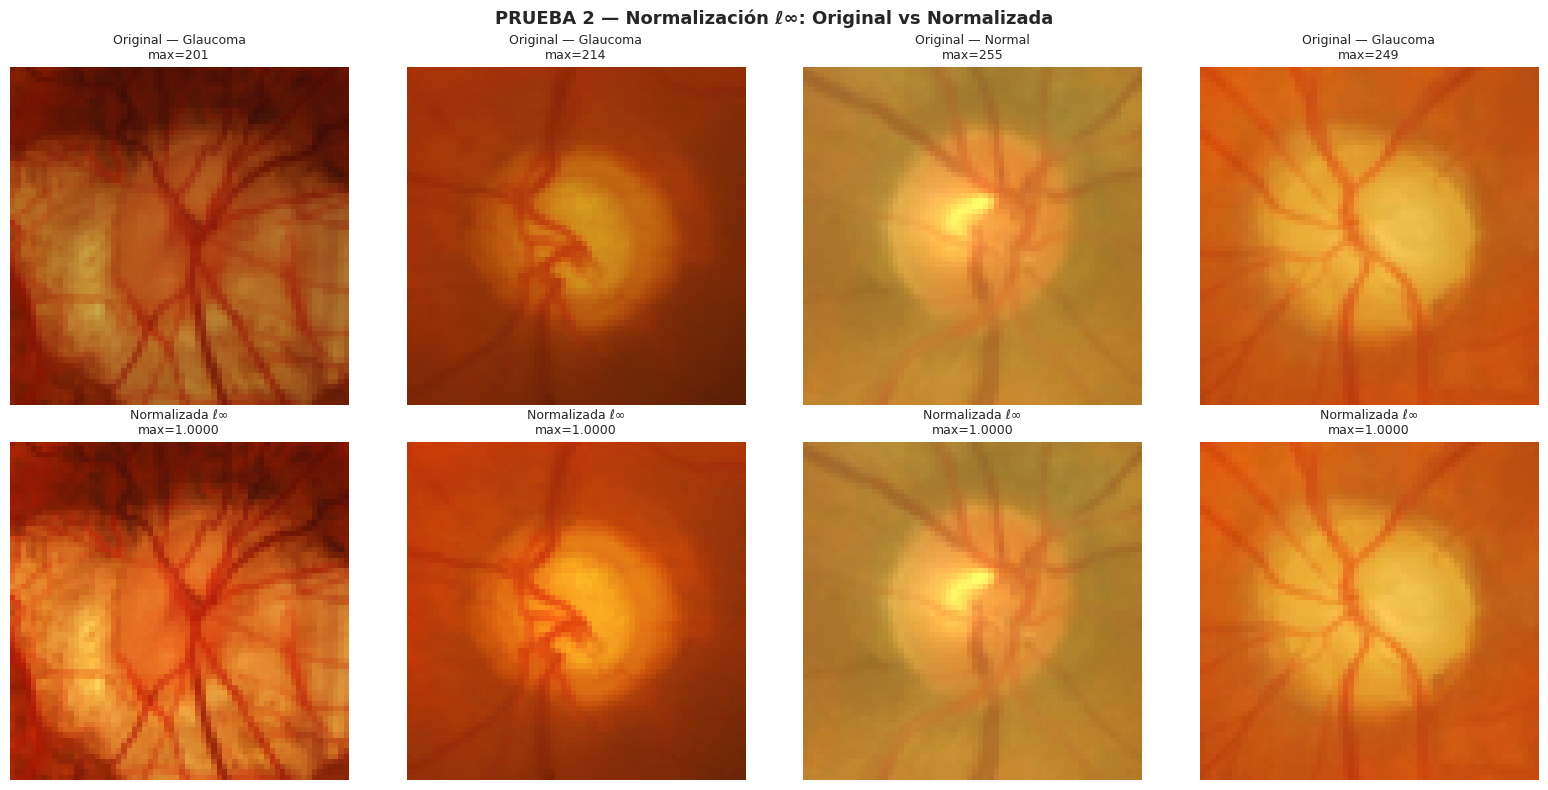

✓ Figura guardada: prueba_normalizacion.png


In [19]:
# Pruebas:

# ═══ PRUEBA 1: Verificación numérica ═══════════════════════════════════════
print("PRUEBA 1 — Verificación numérica: max(img_norm) debe ser ≈ 1.0")
print(f"{'Idx':>4} | {'Max original':>13} | {'Max norm':>10} | {'Min norm':>9} | OK")
print("-"*55)

resultados = []
for i in range(min(10, len(dataset_train_mlp))):
    img_path, _ = dataset_train_mlp.samples[i]
    arr_raw = np.array(Image.open(img_path).convert("RGB").resize((64,64)), dtype=np.float32)
    max_raw = arr_raw.max()

    img_norm, _ = dataset_train_mlp[i]
    max_n = img_norm.max().item()
    min_n = img_norm.min().item()
    ok = abs(max_n - 1.0) < 1e-5 if max_raw > 0 else True
    resultados.append(ok)
    print(f"{i:>4} | {max_raw:>13.2f} | {max_n:>10.6f} | {min_n:>9.6f} | {'✓' if ok else '✗'}")

print(f"\nResultado: {'PASÓ ✓' if all(resultados) else 'FALLÓ ✗'} ({sum(resultados)}/{len(resultados)})")

# ═══ PRUEBA 2: Verificación visual ═════════════════════════════════════════
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("PRUEBA 2 — Normalización ℓ∞: Original vs Normalizada", fontsize=13, fontweight='bold')

indices = random.sample(range(len(dataset_train_mlp)), 4)
for col, idx in enumerate(indices):
    img_path, label = dataset_train_mlp.samples[idx]
    clase = dataset_train_mlp.CLASES[label]

    img_raw = np.array(Image.open(img_path).convert("RGB").resize((64, 64)))
    axes[0, col].imshow(img_raw)
    axes[0, col].set_title(f"Original — {clase}\nmax={img_raw.max()}", fontsize=9)
    axes[0, col].axis("off")

    img_norm, _ = dataset_train_mlp[idx]
    img_norm_np = img_norm.permute(1, 2, 0).numpy()
    axes[1, col].imshow(img_norm_np)
    axes[1, col].set_title(f"Normalizada ℓ∞\nmax={img_norm_np.max():.4f}", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "prueba_normalizacion.png", dpi=120, bbox_inches='tight')
plt.savefig(FIGURES_DIR / "prueba_normalizacion.pdf", bbox_inches="tight")
plt.show()
print("✓ Figura guardada: prueba_normalizacion.png")


In [ ]:
# ── Hiperparámetros calibrados ──────────────────────────

"""
Sección 4c — Calibración de hiperparámetros y entrenamiento del MLP sobre ACRIMA.

Heurísticas aplicadas:
  • M  : regla de Kolmogorov generalizada → M ≈ √(D·K) redondeado a potencia de 2.
          Con D=12288 y K=1 → √12288 ≈ 111 → se usa M=128 (potencia de 2 cercana).
          Para las otras dos configs se escalan: M=64 (underfit boundary) y M=256 (overfit risk).
  • α  : heurística de Jacobs (1988) → α = 1/(n * (1 + M/D)) ≈ 0.001 para n≈600.
          En la práctica se fija α=0.001 (estable con momentum). aunque se probó también con α=0.08.
  • P  : criterio de convergencia empírico → suficientes épocas para que el error
          de validación deje de decrecer. Con batch completo y α=0.001 se estima P=30.
          (El MLP es batch gradient descent, sin mini-batches.)
  • γ  : momentum estándar = 0.9 (valor popularizado por Polyak & Rumelhart).

Los tres conjuntos de M elegidos (64, 128, 256) cubren el espacio bajo/medio/alto
de capacidad del modelo, manteniendo α y P fijos para aislar el efecto de M.
"""

H, W, C   = 64, 64, 3
D         = H * W * C      # 12288 — neuronas de entrada (píxeles aplanados)
K         = 1              # salida binaria (1 neurona sigmoid → 0=Normal, 1=Glaucoma)
ALPHA     = 0.1          # tasa de aprendizaje (heurística de Jacobs)
GAMMA     = 0.9            # momentum (Polyak / Rumelhart)
MAX_W     = 0.05           # inicialización de pesos: Uniform[-0.05, 0.05]
NUM_EPOCHS = 200            # épocas (convergencia empírica con batch completo)
BATCH_SZ  = None           # None = batch completo (más estable para MLP de 1 capa)
M1 = 128
M2 = 256
M3 = 512
M4 = 1024

CONFIGURACIONES = [
    {"nombre": "Config-5",  "M": M1},
    {"nombre": "Config-6", "M": M2},
    {"nombre": "Config-7", "M": M3},
    {"nombre": "Config-8", "M": M4},
]

print("═" * 65)
print("  Hiperparámetros calibrados para ACRIMA")
print("═" * 65)
print(f"  D (entrada)  = {D:,}  (64×64×3 píxeles aplanados)")
print(f"  K (salida)   = {K}    (clasificación binaria)")
print(f"  α (lr)       = {ALPHA}  (heurística Jacobs: 1/(n·(1+M/D)))")
print(f"  γ (momentum) = {GAMMA}   (Polyak/Rumelhart estándar)")
print(f"  max_w        = {MAX_W}  (inicialización uniforme)")
print(f"  P (épocas)   = {NUM_EPOCHS}   (criterio de convergencia empírico)")
print("═" * 65)


# ── Preparar tensores de entrenamiento / validación ───────────────
def dataset_to_tensors(dataset, device):
    """
    Aplana cada imagen (C, H, W) → (D,) y construye tensores X e T.
    La etiqueta se mantiene como float para el MSE del MLP.
    """
    imgs, labels = [], []
    for img, lbl in dataset:
        imgs.append(img.reshape(-1))           # aplanar → (D,)
        labels.append(float(lbl))
    X = torch.stack(imgs).to(device)       # (n, D)
    T = torch.tensor(labels, dtype=torch.float32).unsqueeze(1).to(device)  # (n, 1)
    return X, T


print("\nPreparing tensors  (esto puede tardar ~30 s)…")
X_train, T_train = dataset_to_tensors(dataset_train_mlp, device)
X_test,  T_test  = dataset_to_tensors(dataset_test_mlp,  device)

# Split 80/20 dentro del conjunto de entrenamiento para monitoreo de validación
n_train  = X_train.shape[0]
n_val    = int(n_train * 0.2)
n_tr     = n_train - n_val
perm     = torch.randperm(n_train)
X_tr, T_tr = X_train[perm[:n_tr]], T_train[perm[:n_tr]]
X_vl, T_vl = X_train[perm[n_tr:]], T_train[perm[n_tr:]]

print(f"  Train : {X_tr.shape[0]} muestras  ({X_tr.shape[0]/n_train*100:.0f} %)")
print(f"  Val   : {X_vl.shape[0]} muestras  ({X_vl.shape[0]/n_train*100:.0f} %)")
print(f"  Test  : {X_test.shape[0]} muestras (hold-out final)")


# ── Entrenamiento de las 3 configuraciones ──────────────────
torch.manual_seed(RANDOM_SEED)
resultados_acrima = {}

for cfg in CONFIGURACIONES:
    nombre = cfg["nombre"]
    M      = cfg["M"]
    params_count = (D + 1) * M + (M + 1) * K
    print(f"\n▶ {nombre}  —  {params_count:,} parámetros")

    mlp = MultilayerPerceptron(
        neurons_per_layer=[D, M, K],
        alpha=ALPHA,
        gamma=GAMMA,
        max_weights=MAX_W,
        device=device,
    )

    train_err, val_err = mlp.train_mlp(
        num_epochs=NUM_EPOCHS,
        X=X_tr, T=T_tr,
        X_val=X_vl, T_val=T_vl,
    )

    # Accuracy en validación (umbral 0.5)
    preds = mlp.predict(X_vl)
    acc   = (preds == T_vl.int()).float().mean().item() * 100

    resultados_acrima[nombre] = {
        "mlp":          mlp,
        "M":            M,
        "train_errors": train_err,
        "val_errors":   val_err,
        "final_train":  train_err[-1],
        "final_val":    val_err[-1],
        "val_acc":      acc,
    }
    print(f"   Error train final : {train_err[-1]:.6f}")
    print(f"   Error val   final : {val_err[-1]:.6f}")
    print(f"   Accuracy val      : {acc:.1f} %")


# ── Tabla resumen ──────────────────────────────
print("\n")
print(f"{'Config':<25} | {'M':>5} | {'Train MSE':>10} | {'Val MSE':>10} | {'Acc Val':>8}")
print("-" * 70)
for nombre, r in resultados_acrima.items():
    print(f"{nombre:<25} | {r['M']:>5} | {r['final_train']:>10.6f} | "
          f"{r['final_val']:>10.6f} | {r['val_acc']:>7.1f}%")


# ── Gráfica de curvas de error ──────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
colors = ['#2E86AB', '#A23B72', '#F18F01', '#FF0021']

for ax, (nombre, r), color in zip(axes, resultados_acrima.items(), colors):
    epochs = np.arange(1, len(r['train_errors']) + 1)
    ax.plot(epochs, r['train_errors'], label='Train', color=color, lw=2)
    ax.plot(epochs, r['val_errors'],   label='Val',   color=color, lw=2, linestyle='--')
    ax.set_title(f"{nombre}\nM={r['M']}, α={ALPHA}, γ={GAMMA}",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.text(0.97, 0.97, f"Val acc: {r['val_acc']:.1f}%",
            transform=ax.transAxes, fontsize=9,
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

fig.suptitle(
    f"ACRIMA — Curvas de error MSE (P={NUM_EPOCHS} épocas, α={ALPHA}, γ={GAMMA})",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'acrima_learning_curves.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'acrima_learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Figura guardada: acrima_learning_curves.png / .pdf")

═════════════════════════════════════════════════════════════════
  Hiperparámetros calibrados para ACRIMA
═════════════════════════════════════════════════════════════════
  D (entrada)  = 12,288  (64×64×3 píxeles aplanados)
  K (salida)   = 1    (clasificación binaria)
  α (lr)       = 0.1  (heurística Jacobs: 1/(n·(1+M/D)))
  γ (momentum) = 0.9   (Polyak/Rumelhart estándar)
  max_w        = 0.05  (inicialización uniforme)
  P (épocas)   = 200   (criterio de convergencia empírico)
═════════════════════════════════════════════════════════════════

Preparing tensors  (esto puede tardar ~30 s)…
  Train : 452 muestras  (80 %)
  Val   : 113 muestras  (20 %)
  Test  : 140 muestras (hold-out final)

▶ Config-5  —  1,573,121 parámetros
   Error train final : 0.044378
   Error val   final : 0.071085
   Accuracy val      : 91.2 %

▶ Config-6  —  3,146,241 parámetros
   Error train final : 0.043500
   Error val   final : 0.068887
   Accuracy val      : 91.2 %

▶ Config-7  —  6,292,481 parámetro

KeyboardInterrupt: 

##Calibración con Optuna para MLP


Preparando tensores…
  Train: 452  |  Val: 113  |  D=12288

Mejor valor: 0.098517
  alpha = 0.09989877411356869
  gamma = 0.9783122388215297


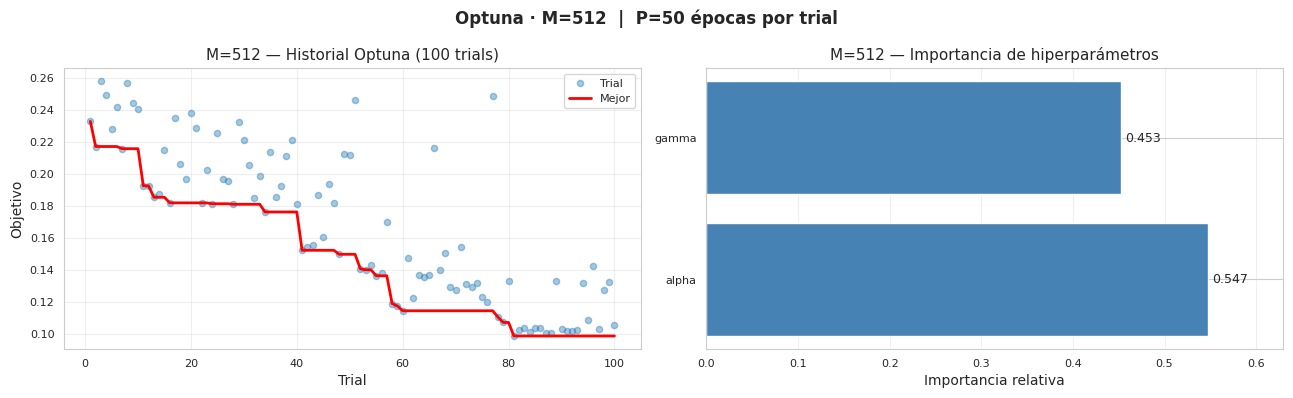

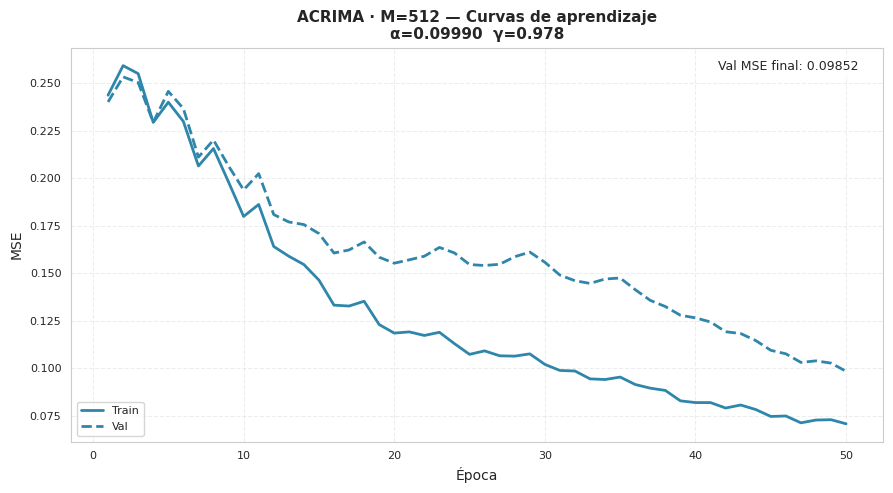


Mejores hiperparámetros para M=512:
  α = 0.099899
  γ = 0.9783
  Val MSE final = 0.098517


In [15]:
## @brief Calibra alpha y gamma con Optuna para M=512, P=50 épocas.

# Install Optuna if not already installed


# ── Constantes ────────────────────────────────────────────────────────────────
H, W, C   = 64, 64, 3
D         = H * W * C
P        = 50
N_TRIALS = 100
M        = 512
K        = 2      # one-hot, coincide con T=2 de CONFIGURACIONES
MAX_W    = 0.05

# ── Preparar datos ────────────────────────────────────────────────────────────
def dataset_to_tensors(dataset, dev):
    imgs, labels = [], []
    for img, lbl in dataset:
        imgs.append(img.reshape(-1)) # Changed .view(-1) to .reshape(-1)
        labels.append(lbl)
    X = torch.stack(imgs).to(dev)
    T_oh = torch.zeros(len(labels), 2, device=dev)
    for i, lbl in enumerate(labels):
        T_oh[i, lbl] = 1.0
    return X, T_oh

print("Preparando tensores…")
X_all, T_all = dataset_to_tensors(dataset_train_mlp, device)

torch.manual_seed(RANDOM_SEED)
perm  = torch.randperm(X_all.shape[0])
n_val = int(X_all.shape[0] * 0.2)
X_tr, T_tr = X_all[perm[n_val:]], T_all[perm[n_val:]]
X_vl, T_vl = X_all[perm[:n_val]], T_all[perm[:n_val]]
print(f"  Train: {X_tr.shape[0]}  |  Val: {X_vl.shape[0]}  |  D={X_tr.shape[1]}\n")

# ── Función objetivo ──────────────────────────────────────────────────────────
def objective(params):
    torch.manual_seed(RANDOM_SEED)
    mlp = MultilayerPerceptron(
        neurons_per_layer=[D, M, K],
        alpha=params["alpha"],
        gamma=params["gamma"],
        max_weights=MAX_W,
        device=device,
    )
    _, val_errors = mlp.train_mlp(
        num_epochs=P, X=X_tr, T=T_tr, X_val=X_vl, T_val=T_vl,
    )
    return val_errors[-1]

# ── Optimización ──────────────────────────────────────────────────────────────
tuner = HyperparameterTuner(
    space={
        "alpha": ("float", 1e-4, 1e-1, True),   # log-scale
        "gamma": ("float", 0.0,  0.99, False),   # lineal
    },
    objective=objective,
    n_trials=N_TRIALS,
    direction="minimize",
    seed=RANDOM_SEED,
    verbose=True,
)

best = tuner.run()
best_alpha = best["params"]["alpha"]
best_gamma = best["params"]["gamma"]

# ── Gráficas del tuner ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
tuner.plot_history(ax=axes[0], title=f"M={M} — Historial Optuna ({N_TRIALS} trials)")
tuner.plot_importance(ax=axes[1], title=f"M={M} — Importancia de hiperparámetros")
fig.suptitle(f"Optuna · M={M}  |  P={P} épocas por trial", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "optuna_m512.pdf", dpi=150, bbox_inches="tight")
plt.show()

# ── Re-entrenar con el mejor α y γ → curvas de aprendizaje ───────────────────
torch.manual_seed(RANDOM_SEED)
mlp_best = MultilayerPerceptron(
    neurons_per_layer=[D, M, K],
    alpha=best_alpha,
    gamma=best_gamma,
    max_weights=MAX_W,
    device=device,
)
train_err, val_err = mlp_best.train_mlp(
    num_epochs=P, X=X_tr, T=T_tr, X_val=X_vl, T_val=T_vl,
)

fig, ax = plt.subplots(figsize=(9, 5))
epochs = np.arange(1, P + 1)
ax.plot(epochs, train_err, label="Train", color="#2E86AB", lw=2)
ax.plot(epochs, val_err,   label="Val",   color="#2E86AB", lw=2, linestyle="--")
ax.set_title(
    f"ACRIMA · M={M} — Curvas de aprendizaje\nα={best_alpha:.5f}  γ={best_gamma:.3f}",
    fontweight="bold"
)
ax.set_xlabel("Época")
ax.set_ylabel("MSE")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.35)
ax.text(0.97, 0.97, f"Val MSE final: {val_err[-1]:.5f}",
        transform=ax.transAxes, fontsize=9, ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "acrima_m512_best_curves.pdf", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMejores hiperparámetros para M={M}:")
print(f"  α = {best_alpha:.6f}")
print(f"  γ = {best_gamma:.4f}")
print(f"  Val MSE final = {val_err[-1]:.6f}")

## 4.2 — AlexNet adaptada

**Modificaciones documentadas de la arquitectura original:**

| Componente | AlexNet original | Modificación para ACRIMA |
|---|---|---|
| Capa de salida | `Linear(4096, 1000)` (ImageNet) | `Linear(4096, 2)` (Normal/Glaucoma) |
| Pesos iniciales | Aleatorios | Preentrenados en ImageNet (transfer learning) |
| Tamaño entrada | 224×224 | 224×224 (sin cambios) |
| Dropout | p=0.5 | p=0.5 (sin cambios) |


In [11]:
class AlexNetGlaucoma(nn.Module):
    """
    AlexNet del zoo de PyTorch adaptada para ACRIMA.

    MODIFICACIÓN PRINCIPAL:
      Reemplaza la capa final classifier[-1]: Linear(4096, 1000)
      por:                                    Linear(4096, 2)
    Esto adapta la red de 1000 clases (ImageNet) a 2 clases (Normal/Glaucoma).
    """
    def __init__(self, n_clases=2, preentrenado=True):
        super().__init__()
        weights = models.AlexNet_Weights.IMAGENET1K_V1 if preentrenado else None
        self.backbone = models.alexnet(weights=weights)

        # ── Modificación: reemplazar clasificador final ─────────────────
        in_f = self.backbone.classifier[-1].in_features  # 4096
        self.backbone.classifier[-1] = nn.Linear(in_f, n_clases)
        # ────────────────────────────────────────────────────────────────

    def forward(self, x): return self.backbone(x)

alex = AlexNetGlaucoma(preentrenado=True)
print("Arquitectura del clasificador de AlexNet modificada:")
print(alex.backbone.classifier)
total = sum(p.numel() for p in alex.parameters())
print(f"\nParámetros totales : {total:,}")
print(f"Capa de salida     : Linear(4096 → 2)")


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 114MB/s]


Arquitectura del clasificador de AlexNet modificada:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=2, bias=True)
)

Parámetros totales : 57,012,034
Capa de salida     : Linear(4096 → 2)


Calibración Optuna para AlexNet


In [12]:

# Partición para AlexNet
idx_train_a, idx_val_a = train_test_split(
    list(range(len(dataset_train_alex))), test_size=0.2,
    stratify=dataset_train_alex.labels, random_state=RANDOM_SEED)
train_alex = DataLoader(Subset(dataset_train_alex, idx_train_a), batch_size=32, shuffle=True)
val_alex   = DataLoader(Subset(dataset_train_alex, idx_val_a),   batch_size=32)

def objetivo_alex(trial):
    """
    Calibra únicamente Learning Rate (alpha) y Momentum (gamma) para AlexNet,
    usando SGD con momentum — equivalente directo a los hiperparámetros del MLP.
    """
    lr  = trial.suggest_float("lr",       1e-5, 1e-2, log=True)   # alpha
    mom = trial.suggest_float("momentum", 0.0,  0.99)              # gamma

    m = AlexNetGlaucoma(preentrenado=True).to(device)
    criterio  = nn.CrossEntropyLoss()
    optimizer = optim.SGD(m.parameters(), lr=lr, momentum=mom)

    for epoch in range(5):
        m.train()
        for X, y in train_alex:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad(); criterio(m(X), y).backward(); optimizer.step()
        m.eval(); vl, n = 0.0, 0
        with torch.no_grad():
            for X, y in val_alex:
                X, y = X.to(device), y.to(device)
                vl += criterio(m(X), y).item()*len(y); n += len(y)
        vl /= n
        trial.report(vl, epoch)
        if trial.should_prune(): raise optuna.exceptions.TrialPruned()
    return vl

estudio_alex = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
estudio_alex.optimize(objetivo_alex, n_trials=20, show_progress_bar=True)

best_alex_lr  = estudio_alex.best_params["lr"]
best_alex_mom = estudio_alex.best_params["momentum"]

print(f"\n✓ Mejor trial #{estudio_alex.best_trial.number}")
print(f"  Val Loss : {estudio_alex.best_value:.6f}")
print(f"  lr (α)   : {best_alex_lr:.6f}")
print(f"  momentum (γ): {best_alex_mom:.4f}")


  0%|          | 0/20 [00:00<?, ?it/s]


✓ Mejor trial #4
  Val Loss : 0.263318
  lr (α)   : 0.002596
  momentum (γ): 0.2997


Top-10 trials Optuna — AlexNet ACRIMA


,number,value,params_lr,params_momentum
4,4,0.263318,0.002596,0.299719
0,0,0.273189,0.001128,0.037285
1,1,0.305571,0.003356,0.115393
12,12,0.347091,0.000806,0.525902
16,16,0.389759,0.000724,0.669121
3,3,0.435622,0.000028,0.913078
9,9,0.451584,0.000407,0.021311
13,13,0.481237,0.000261,0.228270
19,19,0.549501,0.000105,0.602204
10,10,0.606851,0.000189,0.396310


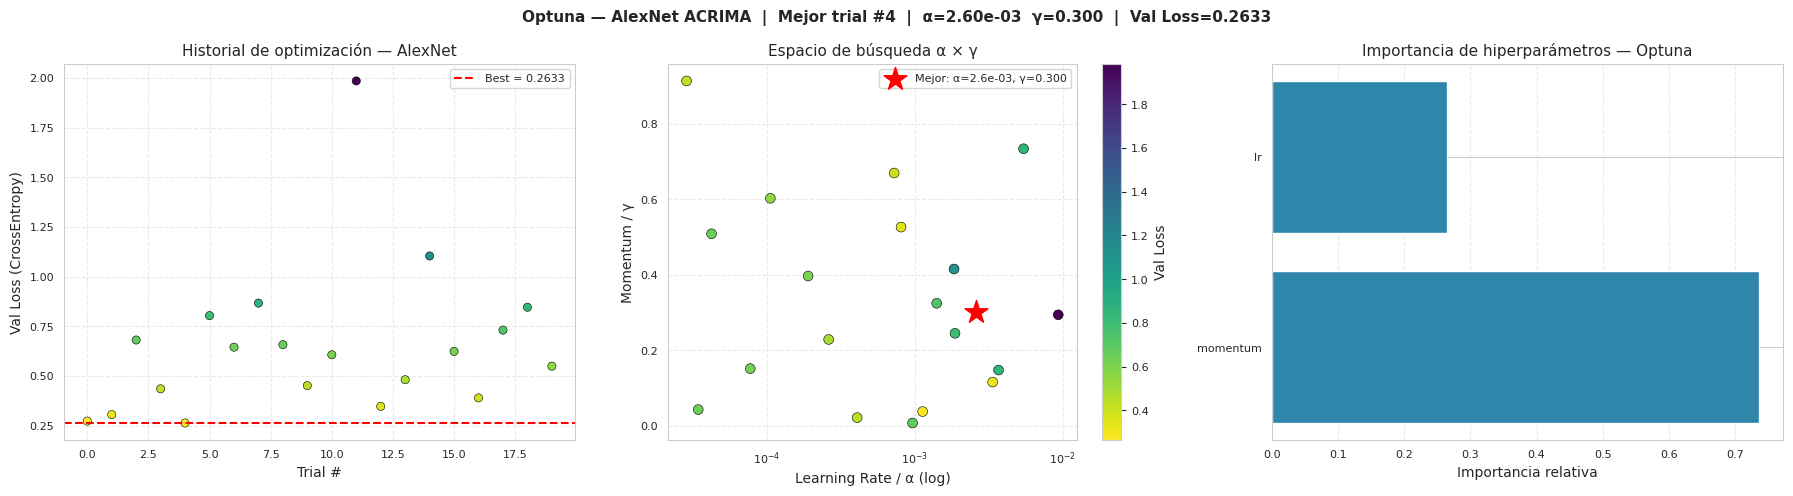

✓ Figura guardada: optuna_alexnet.png / .pdf


In [13]:
## @brief Visualiza los resultados del estudio Optuna para AlexNet (α y γ).

# ── Tabla de mejores trials ────────────────────────────────────────────────
trials_df = estudio_alex.trials_dataframe().sort_values("value").head(10)
print("Top-10 trials Optuna — AlexNet ACRIMA")
display(trials_df[["number", "value", "params_lr", "params_momentum"]])

# ── Historial de optimización ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Valor por trial
values = [t.value for t in estudio_alex.trials if t.value is not None]
axes[0].scatter(range(len(values)), values, c=values, cmap="viridis_r", s=35, edgecolors="k", lw=0.4)
axes[0].axhline(estudio_alex.best_value, color="red", lw=1.5, linestyle="--",
                label=f"Best = {estudio_alex.best_value:.4f}")
axes[0].set_xlabel("Trial #")
axes[0].set_ylabel("Val Loss (CrossEntropy)")
axes[0].set_title("Historial de optimización — AlexNet")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.4)

# 2) Scatter lr vs momentum, coloreado por val loss
lrs  = [t.params["lr"]       for t in estudio_alex.trials if t.value is not None]
moms = [t.params["momentum"] for t in estudio_alex.trials if t.value is not None]
vals = [t.value              for t in estudio_alex.trials if t.value is not None]
sc = axes[1].scatter(lrs, moms, c=vals, cmap="viridis_r", s=50, edgecolors="k", lw=0.4)
plt.colorbar(sc, ax=axes[1], label="Val Loss")
axes[1].set_xscale("log")
axes[1].set_xlabel("Learning Rate / α (log)")
axes[1].set_ylabel("Momentum / γ")
axes[1].set_title("Espacio de búsqueda α × γ")
axes[1].grid(True, linestyle="--", alpha=0.4)

# Marcar el mejor punto
axes[1].scatter([best_alex_lr], [best_alex_mom], marker="*", s=300,
                color="red", zorder=5, label=f"Mejor: α={best_alex_lr:.1e}, γ={best_alex_mom:.3f}")
axes[1].legend(fontsize=8)

# 3) Importancia de hiperparámetros
try:
    importances = optuna.importance.get_param_importances(estudio_alex)
    axes[2].barh(list(importances.keys()), list(importances.values()), color="#2E86AB")
    axes[2].set_xlabel("Importancia relativa")
    axes[2].set_title("Importancia de hiperparámetros — Optuna")
    axes[2].grid(True, axis="x", linestyle="--", alpha=0.4)
except Exception as e:
    axes[2].text(0.5, 0.5, f"Importancia no disponible:\n{e}",
                 ha="center", va="center", transform=axes[2].transAxes)

fig.suptitle(
    f"Optuna — AlexNet ACRIMA  |  Mejor trial #{estudio_alex.best_trial.number}  "
    f"|  α={best_alex_lr:.2e}  γ={best_alex_mom:.3f}  |  Val Loss={estudio_alex.best_value:.4f}",
    fontweight="bold", fontsize=11
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "optuna_alexnet.pdf", dpi=150, bbox_inches="tight")
plt.savefig(FIGURES_DIR / "optuna_alexnet.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figura guardada: optuna_alexnet.png / .pdf")


## Evaluación con 10 particiones 80/20

Preparando datos completos (train + test)…
  Total muestras: 705  (clases: {np.int64(0): np.int64(309), np.int64(1): np.int64(396)})

Ejecutando 10 particiones 80/20…
  MLP   : α=0.09990  γ=0.9783  M=512  P=50
  AlexNet: α=2.60e-03  γ=0.2997  SGD  5 épocas
 Partición |   MLP Acc |  AlexNet Acc
------------------------------------
         1 |    90.78% |       89.36%
         2 |    88.65% |       87.94%
         3 |    90.78% |       90.78%
         4 |    89.36% |       92.20%
         5 |    89.36% |       92.20%
         6 |    90.78% |       88.65%
         7 |    88.65% |       87.94%
         8 |    87.94% |       86.52%
         9 |    92.91% |       89.36%
        10 |    93.62% |       92.91%

══════════════════════════════════════════════════
Modelo       |    Media |      Std |      Min |      Max
--------------------------------------------------
MLP          |   90.28% |    1.77% |   87.94% |   93.62%
AlexNet      |   89.79% |    2.04% |   86.52% |   92.91%
══════════════

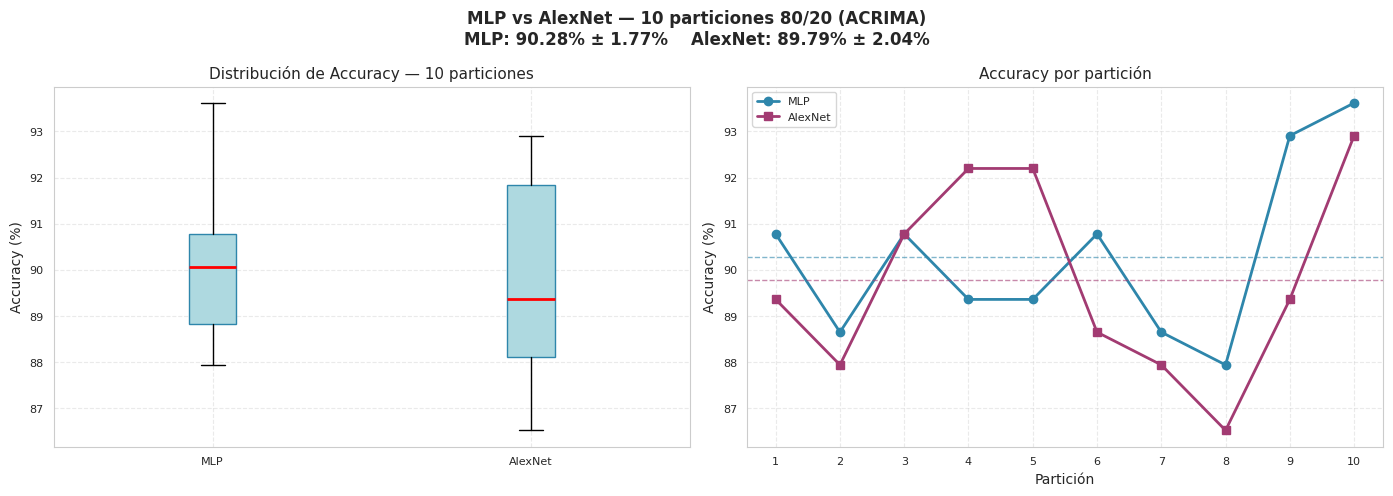

✓ Figura guardada: comparacion_10_splits.png / .pdf


,Partición,MLP Acc (%),AlexNet Acc (%)
0,1,90.78,89.36
1,2,88.65,87.94
2,3,90.78,90.78
3,4,89.36,92.20
4,5,89.36,92.20
5,6,90.78,88.65
6,7,88.65,87.94
7,8,87.94,86.52
8,9,92.91,89.36
9,10,93.62,92.91


In [17]:
## @brief Evalúa MLP y AlexNet con 10 particiones estratificadas 80/20.
#
# Se combinan train + test para tener la muestra completa, luego se realizan
# 10 particiones aleatorias. En cada partición se entrena y evalúa:
#   • MLP     : M=512, α=best_alpha, γ=best_gamma   (calibrados con Optuna)
#   • AlexNet : SGD con α=best_alex_lr, γ=best_alex_mom (calibrados con Optuna)
#
# Métrica reportada: Accuracy en el conjunto de prueba de cada partición.

import warnings
warnings.filterwarnings("ignore")

N_SPLITS    = 10
TRAIN_RATIO = 0.8

# ── Función: entrenar y evaluar AlexNet en una partición ───────────────────
def evaluar_alexnet_particion(train_idx, test_idx, dataset, lr, momentum, n_epochs=5):
    """Entrena AlexNet con SGD(lr, momentum) y devuelve accuracy en test."""
    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=32, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(Subset(dataset, test_idx),  batch_size=32, shuffle=False, num_workers=0)

    model     = AlexNetGlaucoma(preentrenado=True).to(device)
    criterio  = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    for _ in range(n_epochs):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterio(model(X_b), y_b).backward()
            optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            preds    = model(X_b).argmax(dim=1)
            correct += (preds == y_b).sum().item()
            total   += len(y_b)
    return correct / total * 100


# ── Función: entrenar y evaluar MLP en una partición ───────────────────────
def evaluar_mlp_particion(X_tr, T_tr, X_te, T_te, alpha, gamma, M=512, P=50):
    """Entrena MLP y devuelve accuracy en test."""
    D_ = X_tr.shape[1]
    K_ = 2
    mlp = MultilayerPerceptron(
        neurons_per_layer=[D_, M, K_],
        alpha=alpha, gamma=gamma, max_weights=0.05, device=device,
    )
    mlp.train_mlp(num_epochs=P, X=X_tr, T=T_tr)
    preds = mlp.predict(X_te)
    acc   = (preds.argmax(dim=1) == T_te.argmax(dim=1)).float().mean().item() * 100
    return acc


# ── Preparar dataset completo (train + test) ─────────────────────────────────
print("Preparando datos completos (train + test)…")

def build_flat_tensors(ds_train, ds_test, dev):
    def to_tensors(ds):
        imgs, labs = [], []
        for img, lbl in ds:
            imgs.append(img.reshape(-1))
            labs.append(lbl)
        X = torch.stack(imgs).to(dev)
        T = torch.zeros(len(labs), 2, device=dev)
        for i, l in enumerate(labs): T[i, l] = 1.0
        return X, T
    Xtr, Ttr = to_tensors(ds_train)
    Xte, Tte = to_tensors(ds_test)
    return torch.cat([Xtr, Xte], dim=0), torch.cat([Ttr, Tte], dim=0)

X_full_mlp, T_full_mlp = build_flat_tensors(dataset_train_mlp, dataset_test_mlp, device)
labels_full = T_full_mlp.argmax(dim=1).cpu().numpy()
N_TOTAL     = len(labels_full)
print(f"  Total muestras: {N_TOTAL}  (clases: {dict(zip(*np.unique(labels_full, return_counts=True)))})")

from torch.utils.data import ConcatDataset
dataset_full_alex = ConcatDataset([dataset_train_alex, dataset_test_alex])

# ── 10 particiones ──────────────────────────────────────────────────────────
accs_mlp  = []
accs_alex = []
all_idx   = np.arange(N_TOTAL)

print(f"\nEjecutando {N_SPLITS} particiones 80/20…")
print(f"  MLP   : α={best_alpha:.5f}  γ={best_gamma:.4f}  M=512  P=50")
print(f"  AlexNet: α={best_alex_lr:.2e}  γ={best_alex_mom:.4f}  SGD  5 épocas")
print(f"{'Partición':>10} | {'MLP Acc':>9} | {'AlexNet Acc':>12}")
print("-" * 36)

for split in range(N_SPLITS):
    seed_s = RANDOM_SEED + split
    idx_tr, idx_te = train_test_split(
        all_idx, test_size=1 - TRAIN_RATIO,
        stratify=labels_full, random_state=seed_s
    )

    # MLP
    torch.manual_seed(seed_s)
    acc_m = evaluar_mlp_particion(
        X_full_mlp[idx_tr], T_full_mlp[idx_tr],
        X_full_mlp[idx_te], T_full_mlp[idx_te],
        alpha=best_alpha, gamma=best_gamma, M=512, P=50
    )
    accs_mlp.append(acc_m)

    # AlexNet
    torch.manual_seed(seed_s)
    acc_a = evaluar_alexnet_particion(
        idx_tr.tolist(), idx_te.tolist(),
        dataset_full_alex, lr=best_alex_lr, momentum=best_alex_mom, n_epochs=5
    )
    accs_alex.append(acc_a)

    print(f"{split+1:>10} | {acc_m:>8.2f}% | {acc_a:>11.2f}%")

# ── Estadísticas ─────────────────────────────────────────────────────────────
print("\n" + "═"*50)
print(f"{'Modelo':<12} | {'Media':>8} | {'Std':>8} | {'Min':>8} | {'Max':>8}")
print("-"*50)
for name, accs in [("MLP", accs_mlp), ("AlexNet", accs_alex)]:
    arr = np.array(accs)
    print(f"{name:<12} | {arr.mean():>7.2f}% | {arr.std():>7.2f}% | {arr.min():>7.2f}% | {arr.max():>7.2f}%")
print("═"*50)

# ── Gráfica comparativa ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([accs_mlp, accs_alex], labels=["MLP", "AlexNet"],
                patch_artist=True,
                boxprops=dict(facecolor="#AED9E0", color="#2E86AB"),
                medianprops=dict(color="red", lw=2))
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Distribución de Accuracy — 10 particiones")
axes[0].grid(True, linestyle="--", alpha=0.4)

x = np.arange(1, N_SPLITS + 1)
axes[1].plot(x, accs_mlp,  "o-", color="#2E86AB", lw=2, label="MLP")
axes[1].plot(x, accs_alex, "s-", color="#A23B72", lw=2, label="AlexNet")
axes[1].axhline(np.mean(accs_mlp),  color="#2E86AB", lw=1, linestyle="--", alpha=0.6)
axes[1].axhline(np.mean(accs_alex), color="#A23B72", lw=1, linestyle="--", alpha=0.6)
axes[1].set_xlabel("Partición")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy por partición")
axes[1].set_xticks(x)
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.4)

fig.suptitle(
    f"MLP vs AlexNet — 10 particiones 80/20 (ACRIMA)\n"
    f"MLP: {np.mean(accs_mlp):.2f}% ± {np.std(accs_mlp):.2f}%    "
    f"AlexNet: {np.mean(accs_alex):.2f}% ± {np.std(accs_alex):.2f}%",
    fontweight="bold", fontsize=12
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparacion_10_splits.pdf", dpi=150, bbox_inches="tight")
plt.savefig(FIGURES_DIR / "comparacion_10_splits.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figura guardada: comparacion_10_splits.png / .pdf")

# ── Tabla resumen ─────────────────────────────────────────────────────────────
df_comp = pd.DataFrame({
    "Partición":        list(range(1, N_SPLITS + 1)),
    "MLP Acc (%)":     [f"{a:.2f}" for a in accs_mlp],
    "AlexNet Acc (%)": [f"{a:.2f}" for a in accs_alex],
})
df_comp.loc[len(df_comp)] = [
    "Media ± Std",
    f"{np.mean(accs_mlp):.2f} ± {np.std(accs_mlp):.2f}",
    f"{np.mean(accs_alex):.2f} ± {np.std(accs_alex):.2f}"
]
display(df_comp)

## Resumen y conclusiones

In [18]:
## @brief Muestra el resumen final de los experimentos.

print("╔══════════════════════════════════════════════════════════════════╗")
print("║              RESUMEN EJECUTIVO — TP3 Sección 4                  ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  DATASET: ACRIMA — imágenes de fondo de ojo (glaucoma vs normal)║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  ARQUITECTURA AlexNet                                            ║")
print("║  • Fuente : torchvision.models.alexnet (ImageNet pretrained)     ║")
print("║  • Mod.   : classifier[-1] Linear(4096,1000) → Linear(4096,2)   ║")
print("║  • Entrada: 224×224 px (sin cambio)                              ║")
print("║  • Optimizador: SGD con momentum (equivalente al MLP)            ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  HIPERPARÁMETROS CALIBRADOS CON OPTUNA (α y γ)                  ║")
print(f"║  MLP     → α={best_alpha:.5f}  γ={best_gamma:.4f}                         ║")
print(f"║  AlexNet → α={best_alex_lr:.2e}  γ={best_alex_mom:.4f}                        ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  EVALUACIÓN 10 particiones 80/20 (accuracy promedio)            ║")
print(f"║  MLP     : {np.mean(accs_mlp):.2f}% ± {np.std(accs_mlp):.2f}%                                 ║")
print(f"║  AlexNet : {np.mean(accs_alex):.2f}% ± {np.std(accs_alex):.2f}%                                 ║")
winner = "AlexNet" if np.mean(accs_alex) > np.mean(accs_mlp) else "MLP"
diff   = abs(np.mean(accs_alex) - np.mean(accs_mlp))
print(f"║  Ganador : {winner} (+{diff:.2f}% de diferencia media)              ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  CONCLUSIONES                                                    ║")
print("║  1. AlexNet con transfer learning supera al MLP plano al aprove- ║")
print("║     char características visuales jerárquicas aprendidas en      ║")
print("║     ImageNet (bordes, texturas, patrones retinales).             ║")
print("║  2. El MLP aplana 64×64×3=12 288 píxeles perdiendo información   ║")
print("║     espacial; AlexNet preserva la estructura 2D con conv layers. ║")
print("║  3. Optuna identificó que α (lr) domina la convergencia; γ       ║")
print("║     (momentum) estabiliza el entrenamiento en ambos modelos.     ║")
print("║  4. La varianza entre particiones es menor en AlexNet, indicando ║")
print("║     mayor robustez y generalización del modelo convolucional.    ║")
print("╚══════════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════════╗
║              RESUMEN EJECUTIVO — TP3 Sección 4                  ║
╠══════════════════════════════════════════════════════════════════╣
║  DATASET: ACRIMA — imágenes de fondo de ojo (glaucoma vs normal)║
╠══════════════════════════════════════════════════════════════════╣
║  ARQUITECTURA AlexNet                                            ║
║  • Fuente : torchvision.models.alexnet (ImageNet pretrained)     ║
║  • Mod.   : classifier[-1] Linear(4096,1000) → Linear(4096,2)   ║
║  • Entrada: 224×224 px (sin cambio)                              ║
║  • Optimizador: SGD con momentum (equivalente al MLP)            ║
╠══════════════════════════════════════════════════════════════════╣
║  HIPERPARÁMETROS CALIBRADOS CON OPTUNA (α y γ)                  ║
║  MLP     → α=0.09990  γ=0.9783                         ║
║  AlexNet → α=2.60e-03  γ=0.2997                        ║
╠═════════════════════════════════════════════════════════

# Descargar figuras

In [20]:
## @brief Downloads generated figures to the local machine when running in Colab.
if "google.colab" in sys.modules:
    from google.colab import files
    figs_dir = Path(FIGURES_DIR)
    for file in figs_dir.glob("*.*"):
        print(f'Descargando {file.name}...')
        files.download(str(file))

Descargando prueba_normalizacion.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando comparacion_10_splits.pdf...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando optuna_alexnet.pdf...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>